# 白化新息 CUSUM：用于漂移触发的在线适配

**目的。** 本 notebook 总结 2026-04-26 到 2026-04-30 这两天完成的工作：在 SubspaceNet+EKF 在线学习管线中，用 covariance-aware 的 whitened innovation CUSUM trigger 替代硬编码/手动设置的漂移触发方式。

**主要结果。** N=20 验证表明，该 trigger 具备有效的漂移检测能力；但当前 calibration 仍有 2/20 的 no-drift false alarm，因此还不能直接作为最终论文配置。

**PPT 要点。** 这项工作的贡献是一个更有统计解释性的 trigger design 和 calibration workflow，而不是声称当前设置已经全面超过所有 manual baseline。

## 1. 我们打算做什么？

任务起点是一个用于 DoA estimation 的 SubspaceNet+EKF online adaptation pipeline，目标场景是 array-response drift 下的无标签部署。

在这项工作之前，仓库已经具备：

| Component | Status |
| --- | --- |
| SubspaceNet DoA estimator | 已实现。 |
| EKF downstream tracker | 已实现，并且已经输出 innovation 相关统计量。 |
| Online adaptation with pseudo-labels | 已实现。 |
| Automatic drift trigger | 尚未真正解决；online learning 主要仍由 `time_to_learn` 控制。 |

这次任务要把 innovation statistics 接成真正的漂移触发器：

```text
X_i -> SubspaceNet g_psi(X_i) -> EKF tracker -> innovation y_i
                                      |
                                      +-> drift detection
                                      +-> unsupervised adaptation
```

**PPT 要点。** 这个 pipeline 已经有 estimator、tracker 和 online-learning 机制；缺失的是一个有统计依据的 automatic trigger。

## 2. 为什么不能只用手动阈值？

原始 trigger 思路是监控滑动窗口 innovation energy：

$$
\sigma_y^2(i)=\frac{1}{I}\sum_{j=i-I+1}^{i}\|y_j\|^2
$$

当下面条件满足时启动 online adaptation：

$$
\sigma_y^2(i) > \tau_\sigma.
$$

这个做法有三个实际问题：

1. **Manual tuning.** `tau_sigma` 是手动设置的阈值。
2. **Scale sensitivity.** raw innovation magnitude 会受到 EKF uncertainty、measurement noise、SNR、snapshot count 和 checkpoint quality 的影响。
3. **Weak transferability.** 在一个 drift/noise/checkpoint setting 下有效的阈值，换到另一个部署场景可能不再有意义。

**PPT 要点。** Manual `tau_sigma` 可以作为工程 baseline，但它没有 portable false-alarm interpretation。

## 3. 核心想法：whiten the innovation

EKF 已经计算了 innovation covariance：

$$
S_i = P_{i|i-1} + R_{obs}.
$$

与其直接 threshold raw innovation energy，不如用这个 covariance 对 innovation 做 normalization：

$$
c_i = y_i^T S_i^{-1}y_i.
$$

如果 no-drift model calibration 足够好，这个 statistic 应该近似服从自由度为 `M=3` 的 chi-square distribution：

$$
c_i \approx \chi^2(3) \quad \text{under no drift}.
$$

这样检测问题就从：

```text
How large is the raw residual?
```

变成：

```text
How surprising is the residual relative to the EKF uncertainty?
```

**PPT 要点。** Whitening 让 trigger 变成 covariance-aware；同样大小的 residual，在 tracker 不确定和 tracker 很确定时会被不同对待。

## 4. 从 statistic 到 trigger：Page-CUSUM

单个 large residual 可能只是噪声，因此 trigger 使用累积统计量来捕捉 persistent evidence：

$$
G_i = \max(0, G_{i-1} + c_i - b).
$$

当下面条件满足时启动 online adaptation：

$$
G_i > h.
$$

在当前实现中：

| Quantity | Meaning |
| --- | --- |
| `c_i` | whitened innovation statistic |
| `b` | reference value；通过 `b_offset` 实现 |
| `h` | 由 target `p_fa` 推导的 CUSUM threshold |
| `reset_after_trigger` | trigger 后重置 accumulator |

最终用于验证的 candidate：

```yaml
kalman_filter:
  measurement_noise_std_dev: 0.125

online_learning:
  drift_trigger:
    type: whitened_cusum
    p_fa: 1e-6
    dof: 3
    b_offset: 24.0
    reset_after_trigger: true
```

**PPT 要点。** CUSUM 把 whitened innovation 变成 persistent-drift detector，而不是 one-step alarm。

## 5. 代码里是怎么接进去的？

实现上新增了一个 common drift-trigger interface，并支持三种 trigger strategy：

| Strategy | Role |
| --- | --- |
| `time_to_learn` | legacy fixed-window / oracle-style reference。 |
| `sigma_y_sq` | 使用 innovation energy 的 manual threshold baseline。 |
| `whitened_cusum` | 新的 covariance-aware CUSUM trigger。 |

Implementation map：

| Area | File | Purpose |
| --- | --- | --- |
| Trigger strategies | `src/trainer_module/online_learning_parts/drift_trigger.py` | Thresholds、Page-CUSUM、strategy factory。 |
| Pipeline wiring | `src/trainer_module/online_learning_parts/pipeline_run.py` | 把 window-level innovation statistics 喂给选定 trigger。 |
| Metrics / diagnostics | `metrics.py` and dump hooks | 暴露 `c_per_step` 和 per-source diagnostics。 |
| Validation scripts | `scripts/run_trigger_validation.py`, `scripts/aggregate_trigger_results.py`, `scripts/plot_trigger_validation.py` | 运行、聚合、绘制 N=20 validation results。 |
| Config | `SineAccel_whitened_cusum_pretrained_calibrated.yaml` | N=20 validation 使用的 final candidate。 |

**PPT 要点。** 这项贡献不是只停留在公式层面，而是已经接入 actual closed-loop online-learning path。

In [ ]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

CWD = Path.cwd().resolve()
if (CWD / "plan" / "plan_29Apr" / "summary.csv").exists():
    ROOT = CWD
elif (CWD.parent / "plan" / "plan_29Apr" / "summary.csv").exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError("Cannot locate repo root containing plan/plan_29Apr/summary.csv")

SUMMARY_CSV = ROOT / "plan" / "plan_29Apr" / "summary.csv"
FIG_DIR = ROOT / "plan" / "plan_29Apr" / "figures"
NOTEBOOK_FIG_DIR = ROOT / "notebooks" / "figures"
NOTEBOOK_FIG_DIR.mkdir(parents=True, exist_ok=True)

assert SUMMARY_CSV.exists(), SUMMARY_CSV
assert FIG_DIR.exists(), FIG_DIR

In [ ]:
summary = pd.read_csv(SUMMARY_CSV)
summary

ppt_table = summary.copy()
ppt_table["false_alarm_rate"] = ppt_table["false_alarm_rate"].map(lambda x: f"{x:.0%}")
ppt_table["detect_rate"] = ppt_table["detect_rate"].map(lambda x: "-" if pd.isna(x) else f"{x:.0%}")
ppt_table["mean_detection_delay"] = ppt_table["mean_detection_delay"].map(
    lambda x: "-" if pd.isna(x) else f"{x:.2f}"
)
ppt_table["tail5_improve"] = ppt_table["tail5_improve"].map(lambda x: f"{x:.4f}")
ppt_table

,trigger,eta,n_trajectories,false_alarm_rate,detect_rate,mean_detection_delay,tail5_improve
0,sigma_y_sq,0.0,20,10%,-,-,0.0150
1,sigma_y_sq,0.3,20,0%,100%,5.20,0.0514
2,sigma_y_sq,0.6,20,0%,100%,2.25,0.0664
3,sigma_y_sq,1.0,20,0%,100%,2.05,0.0659
4,time_to_learn,0.0,20,100%,-,-,0.0141
5,time_to_learn,0.3,20,0%,100%,1.00,0.0692
6,time_to_learn,0.6,20,0%,100%,1.00,0.0441
7,time_to_learn,1.0,20,0%,100%,1.00,0.0909
8,whitened_cusum,0.0,20,10%,-,-,0.0066
9,whitened_cusum,0.3,20,0%,95%,6.05,0.0603


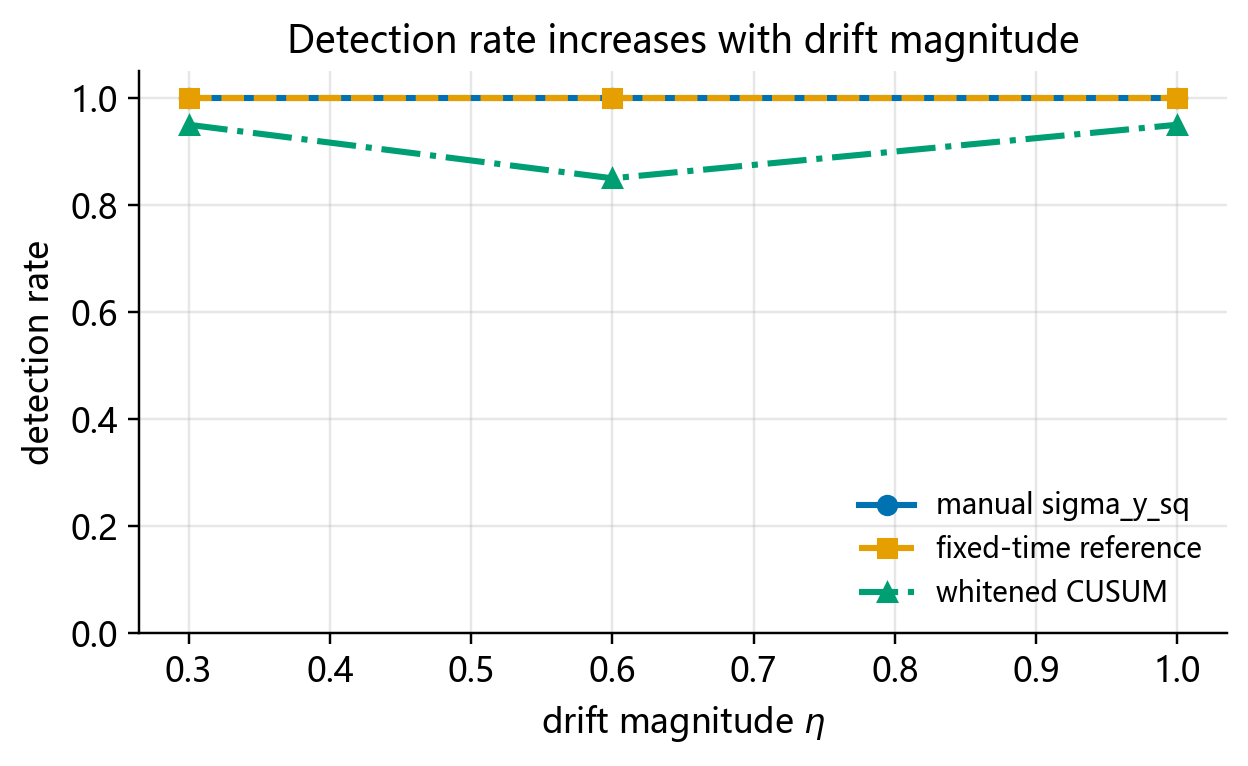

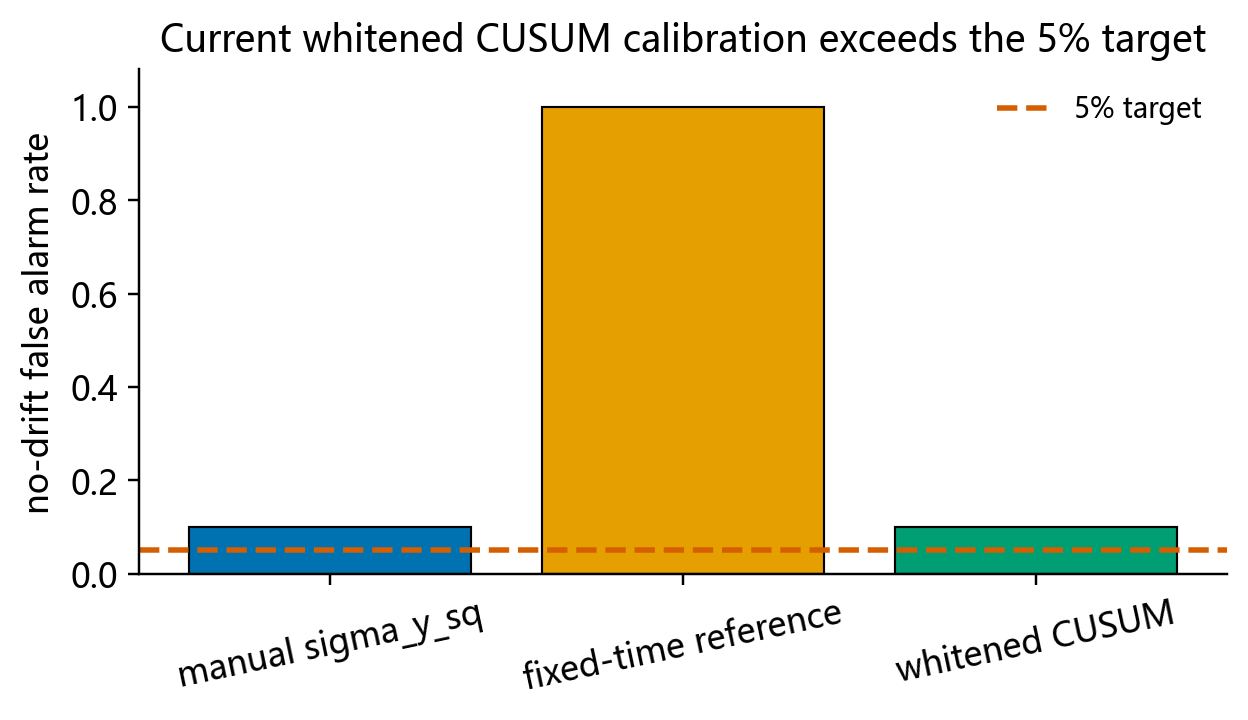

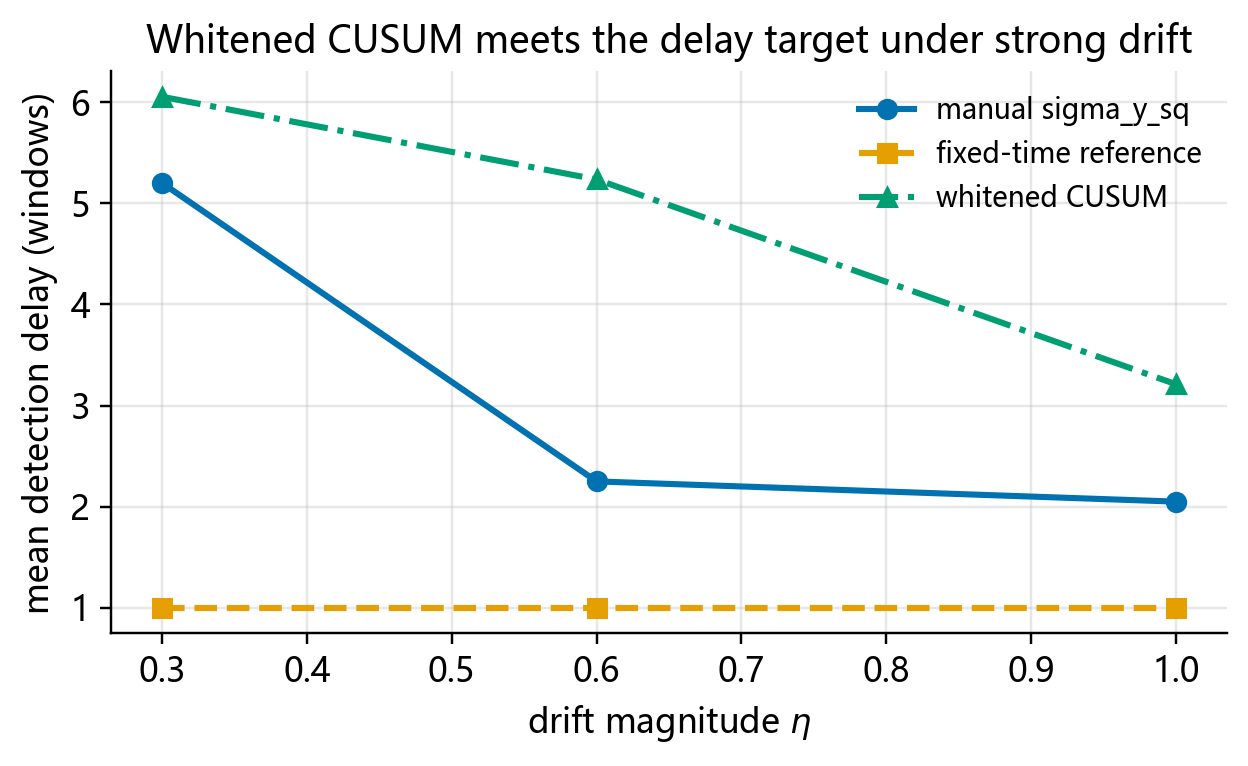

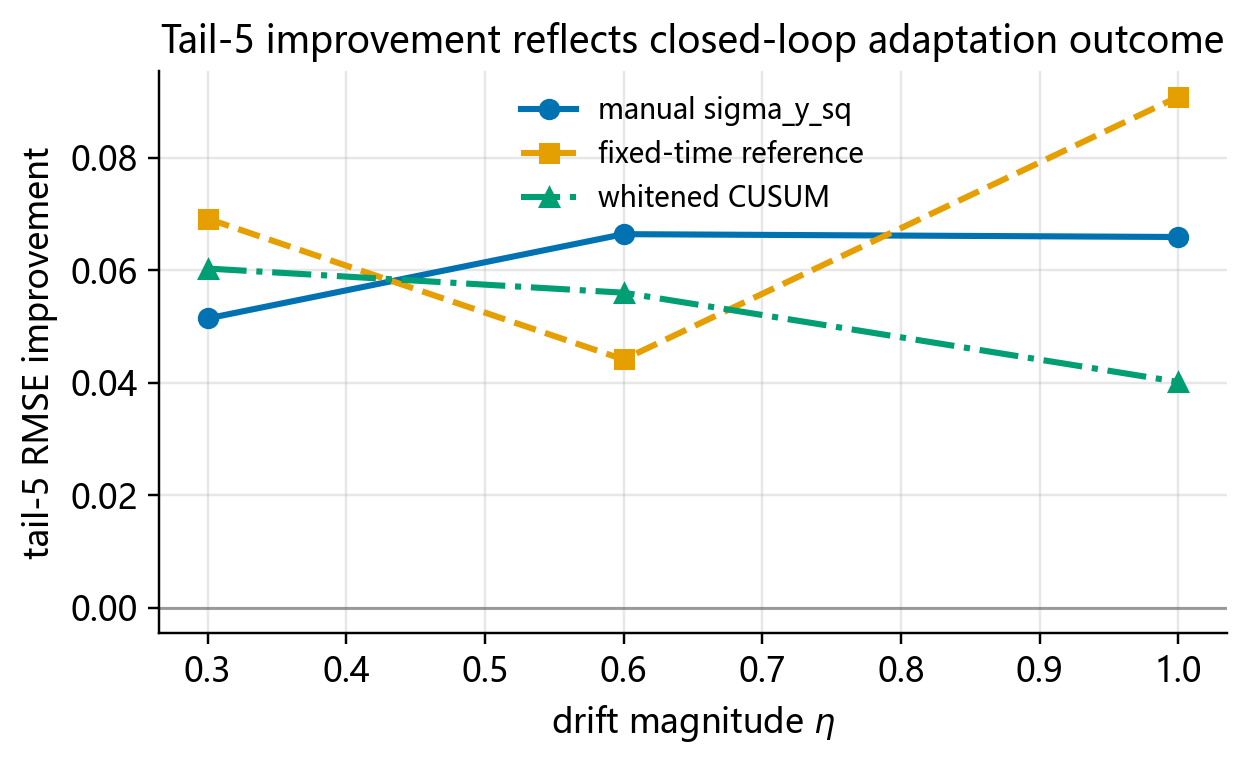

In [ ]:
from matplotlib import font_manager

CN_FONT_CANDIDATES = [
    Path("/mnt/c/Windows/Fonts/msyh.ttc"),
    Path("/mnt/c/Windows/Fonts/simhei.ttf"),
]
for font_path in CN_FONT_CANDIDATES:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        CN_FONT_FAMILY = font_manager.FontProperties(fname=str(font_path)).get_name()
        break
else:
    CN_FONT_FAMILY = "DejaVu Sans"

OKABE_ITO = {
    "sigma_y_sq": "#0072B2",      # blue
    "time_to_learn": "#E69F00",   # orange
    "whitened_cusum": "#009E73",  # green
}

LINE_STYLES = {
    "sigma_y_sq": ("o", "-"),
    "time_to_learn": ("s", "--"),
    "whitened_cusum": ("^", "-."),
}

DISPLAY_NAMES = {
    "sigma_y_sq": "manual sigma_y_sq",
    "time_to_learn": "fixed-time reference",
    "whitened_cusum": "whitened CUSUM",
}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.sans-serif": [CN_FONT_FAMILY, "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"],
    "axes.unicode_minus": False,
})


def save_png(fig, stem: str) -> None:
    fig.savefig(NOTEBOOK_FIG_DIR / f"{stem}.png", bbox_inches="tight")


def plot_detection_rate(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    plot_df = df[(df["eta"] > 0) & df["detect_rate"].notna()]
    for trigger, group in plot_df.groupby("trigger"):
        group = group.sort_values("eta")
        marker, linestyle = LINE_STYLES[trigger]
        ax.plot(
            group["eta"],
            group["detect_rate"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.0,
            markersize=6,
            color=OKABE_ITO[trigger],
            label=DISPLAY_NAMES[trigger],
        )
    ax.set_xlabel(r"drift magnitude $\eta$")
    ax.set_ylabel("detection rate")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="lower right")
    ax.set_title("Detection rate increases with drift magnitude")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_detect_rate_cn")
    return fig


def plot_false_alarm(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    null_df = df[df["eta"] == 0].copy().sort_values("trigger")
    colors = [OKABE_ITO[t] for t in null_df["trigger"]]
    labels = [DISPLAY_NAMES[t] for t in null_df["trigger"]]
    ax.bar(labels, null_df["false_alarm_rate"], color=colors, edgecolor="black", linewidth=0.7)
    ax.axhline(0.05, color="#D55E00", linestyle="--", linewidth=1.8, label="5% target")
    ax.set_ylabel("no-drift false alarm rate")
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis="x", rotation=12)
    ax.legend(frameon=False)
    ax.set_title("Current whitened CUSUM calibration exceeds the 5% target")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_false_alarm_cn")
    return fig


def plot_detection_delay(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    plot_df = df[(df["eta"] > 0) & df["mean_detection_delay"].notna()]
    for trigger, group in plot_df.groupby("trigger"):
        group = group.sort_values("eta")
        marker, linestyle = LINE_STYLES[trigger]
        ax.plot(
            group["eta"],
            group["mean_detection_delay"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.0,
            markersize=6,
            color=OKABE_ITO[trigger],
            label=DISPLAY_NAMES[trigger],
        )
    ax.set_xlabel(r"drift magnitude $\eta$")
    ax.set_ylabel("mean detection delay (windows)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    ax.set_title("Whitened CUSUM meets the delay target under strong drift")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_delay_cn")
    return fig


def plot_tail5_improve(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    plot_df = df[df["eta"] > 0].copy()
    for trigger, group in plot_df.groupby("trigger"):
        group = group.sort_values("eta")
        marker, linestyle = LINE_STYLES[trigger]
        ax.plot(
            group["eta"],
            group["tail5_improve"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.0,
            markersize=6,
            color=OKABE_ITO[trigger],
            label=DISPLAY_NAMES[trigger],
        )
    ax.axhline(0.0, color="#666666", linewidth=1.0, alpha=0.6)
    ax.set_xlabel(r"drift magnitude $\eta$")
    ax.set_ylabel("tail-5 RMSE improvement")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    ax.set_title("Tail-5 improvement reflects closed-loop adaptation outcome")
    fig.tight_layout()
    save_png(fig, "whitened_cusum_tail5_improve_cn")
    return fig


fig_detect = plot_detection_rate(summary)
fig_fa = plot_false_alarm(summary)
fig_delay = plot_detection_delay(summary)
fig_tail5 = plot_tail5_improve(summary)
plt.show()

### Detection rate across drift magnitude

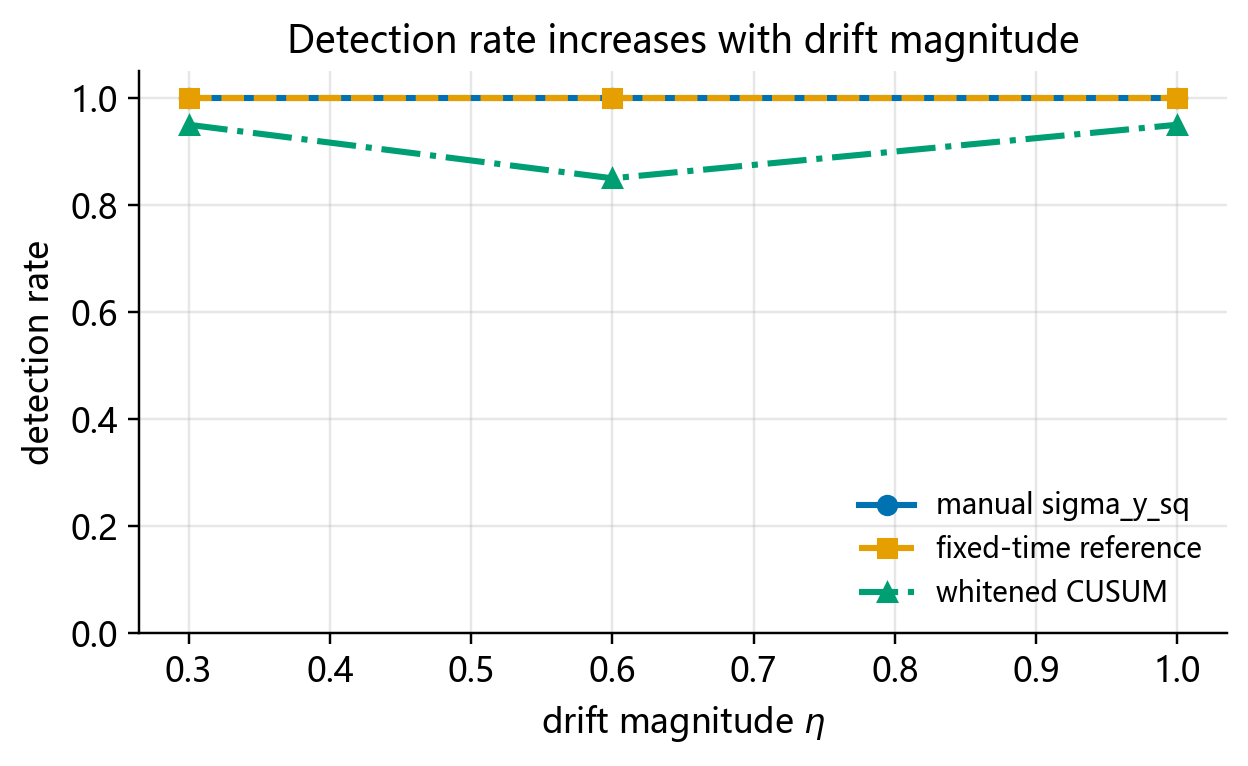

### No-drift false alarm vs 5% target

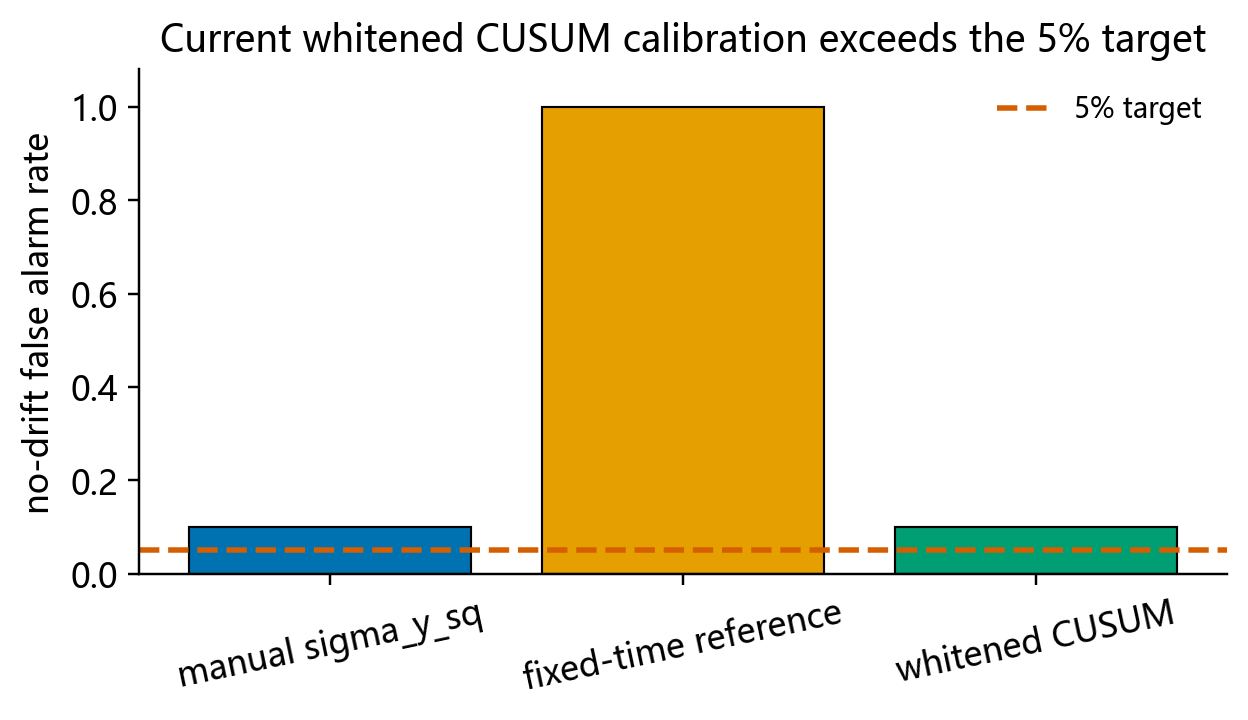

### Mean detection delay in windows

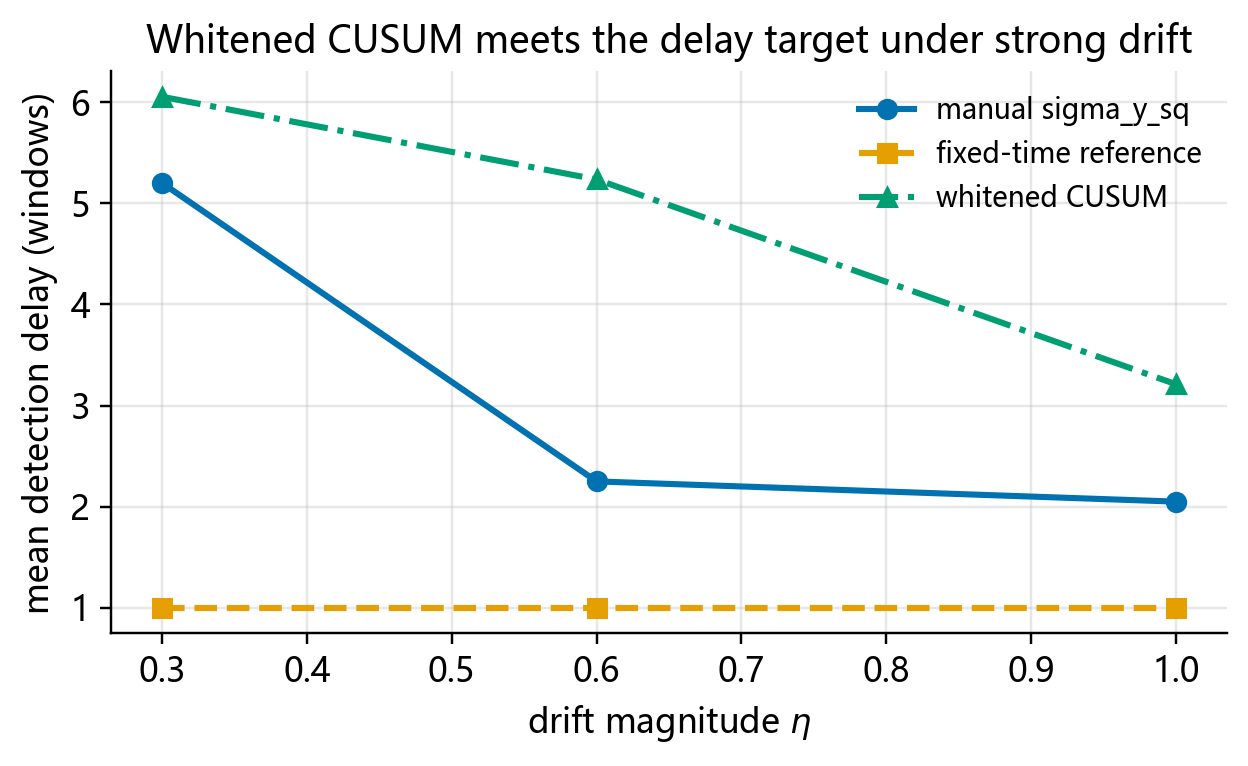

### Tail-5 RMSE improvement

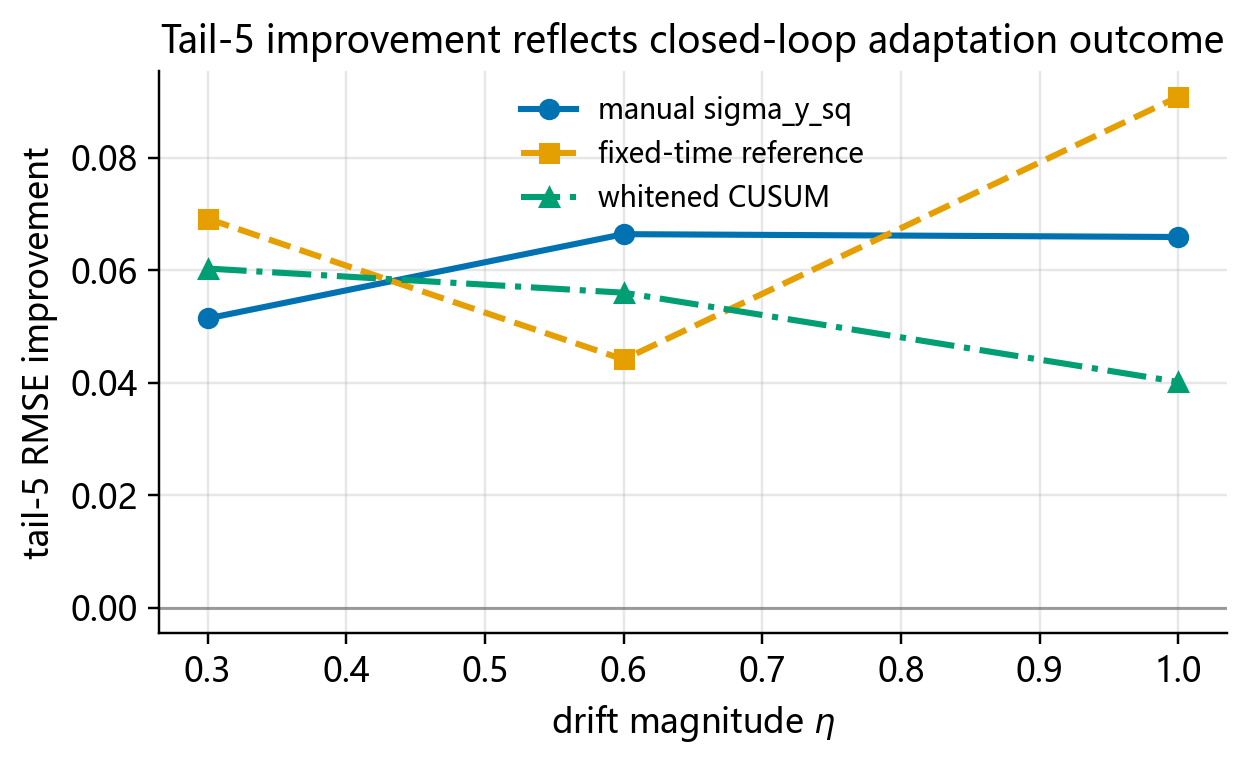

In [ ]:
for fig_name, caption in [
    ("whitened_cusum_detect_rate_cn.png", "Detection rate across drift magnitude"),
    ("whitened_cusum_false_alarm_cn.png", "No-drift false alarm 与 5% target"),
    ("whitened_cusum_delay_cn.png", "Mean detection delay in windows"),
    ("whitened_cusum_tail5_improve_cn.png", "Tail-5 RMSE improvement"),
]:
    fig_path = NOTEBOOK_FIG_DIR / fig_name
    assert fig_path.exists(), fig_path
    display(Markdown(f"### {caption}"))
    display(Image(filename=str(fig_path)))

PPT 图注：

1. **Detection rate.** Whitened CUSUM 在 `eta=1.0` 下达到 95% detection，在 `eta=0.6` 下达到 85%，说明该 trigger 对 medium-to-strong drift 是有效的。
2. **False alarm.** 当前 calibration 在 no-drift 下产生 2/20 false alarms，高于 5% target；这是主要 remaining calibration issue。
3. **Detection delay.** strong drift 的平均检测延迟为 3.21 windows，满足 <=5 windows 的 delay target。
4. **Tail-5 improvement.** 该指标反映 trigger 后的 closed-loop adaptation outcome；当前 whitened CUSUM 有正收益，但并非在所有 drift levels 上超过 manual baseline。


## 6. 做完之后有什么结果？

Validation setting：

| Item | Value |
| --- | --- |
| Checkpoint | `saved_SubspaceNet_trained_20260224_180720.pt` |
| N | 每个 cell 20 条 trajectories |
| Whitened CUSUM calibration | `R_obs=0.125`, `p_fa=1e-6`, `b_offset=24` |

N=20 关键结果：

| Case | Result |
| --- | --- |
| no drift | false alarm = 2/20 = 10%；target 是 <=1/20 = 5% |
| `eta=0.3` | detect rate = 19/20 = 95%；mean delay = 6.05 windows |
| `eta=0.6` | detect rate = 17/20 = 85%；mean delay = 5.24 windows |
| `eta=1.0` | detect rate = 19/20 = 95%；mean delay = 3.21 windows |

Acceptance gates：

| Gate | Target | Result | Status |
| --- | --- | --- | --- |
| strong drift detection | `eta=1.0`, >=18/20 | 19/20 | pass |
| medium drift detection | `eta=0.6`, >=12/20 | 17/20 | pass |
| weak drift | report only | 19/20 | pass |
| strong drift delay | <=5 windows | 3.21 windows | pass |
| no-drift false alarm | <=1/20 | 2/20 | fail |
| detect rate >= `sigma_y_sq` | same eta | lower at all drift levels | fail |

Tail-5 improvement 是 positive but mixed：whitened CUSUM 在 `eta=0.3/0.6/1.0` 下分别为 0.0603/0.0560/0.0402，但不是 consistently best baseline。

Overall: 4/6 gates passed.

**PPT 要点。** detection effectiveness 是可信的，但当前 calibration 还不够 tight，不能作为 final paper-ready setting。

## 7. 和手动阈值相比，有什么好处？

Manual `sigma_y_sq` trigger 和 whitened CUSUM 的作用不同。

| Dimension | Manual `sigma_y_sq > tau_sigma` | Whitened innovation CUSUM |
| --- | --- | --- |
| Statistic | raw/sliding-window innovation energy | covariance-normalized innovation statistic |
| Threshold meaning | empirical/manual | 通过 null-distribution framing 连接到 false-alarm target |
| Transferability | 不同 setting 下需要重新调参 | 更可解释，但 heavy-tailed model residual 下仍需要 calibration |
| Current N=20 detection power | retuned `tau_sigma=12` 后很强：测试 drift levels 下都是 100% | 良好但更低：85-95% |
| Current no-drift false alarm | retuned 后为 2/20 | 当前 calibration 下为 2/20 |
| Best current claim | strong comparator baseline | 更好的 statistical framing 和 calibration workflow |

Important interpretation：

- 不要声称 whitened CUSUM 当前比 `sigma_y_sq` 检测更早或更可靠。
- 可以声称 whitened CUSUM 给出了更清楚的统计解释：residual 是相对于 EKF uncertainty 来判断的，并且 trigger 有 explicit false-alarm-control framing。
- 当前限制在 calibration：真实 SubspaceNet residual 比 ideal chi-square null 更 heavy-tailed，因此 `R_obs` 和 `b_offset` 仍需要 closed-loop tuning。

**PPT 要点。** 好处是 interpretability 和 deployment-oriented calibration，不是当前已经取得 raw detection superiority。

## 8. 最后一页 PPT 信息

### What we planned

用基于 EKF uncertainty 的 whitened innovation CUSUM trigger，替代 manual/fixed online-learning triggers。

### How we did it

1. 提取 EKF pipeline 中已经存在的 innovation statistics。
2. 把 raw residual 转换为 whitened statistic：`c_i = y_i^T S_i^{-1}y_i`。
3. 加入 Page-CUSUM trigger，支持 configurable `p_fa`、`b_offset` 和 reset behavior。
4. 把 trigger 接入 closed-loop SubspaceNet+EKF online-learning pipeline。
5. 在 N=20 trajectories 上验证三种 triggers：`time_to_learn`、`sigma_y_sq` 和 `whitened_cusum`。

### What we found

- Whitened CUSUM 可以有效检测漂移：`eta=1.0` 下 95%，`eta=0.6` 下 85%，`eta=0.3` 下 95%。
- strong-drift delay 达标：3.21 windows。
- 当前 no-drift false alarm 偏高：2/20 = 10%，target <=5%。
- Tail-5 improvement 为正，但 closed-loop adaptation gain 目前是 mixed outcome。
- retuned `sigma_y_sq` 仍然是很强的 detection-power baseline。

### Final framing

这是一个有前景的 statistically interpretable trigger 和 calibration workflow。但在 false alarm 降到 <=1/20 或用更大的 N 验证前，它还不是 final paper configuration。